In [2]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../dataset/train.csv")
#mình đang xử lí file train nên chỉ đọc train thôi nhé
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,69,1,2,2,1,1,1,1,1,1,2,0,0,24.25,1641.80,0
1,1,0,1,0,23,1,0,2,1,1,1,1,1,1,1,0,1,19.30,486.20,0
2,0,1,1,0,47,1,2,1,2,0,0,0,0,0,0,0,2,80.35,3825.85,1
3,1,0,0,1,8,0,1,0,2,0,0,2,0,2,2,1,3,44.55,343.45,0
4,0,0,1,1,72,1,2,0,2,2,2,2,2,2,2,0,1,90.95,6652.45,0


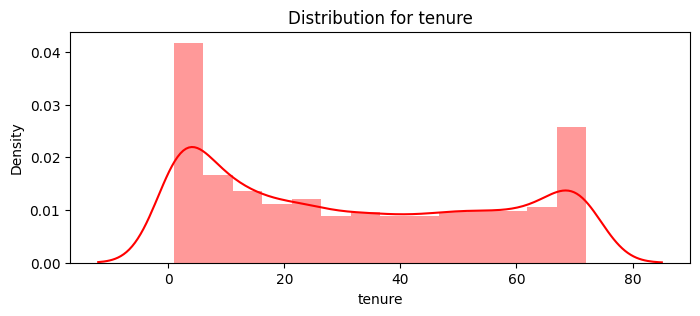

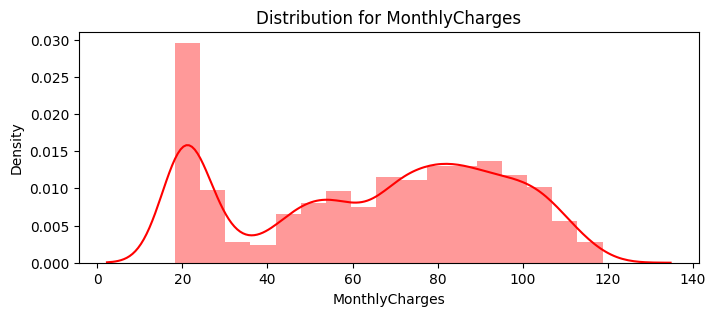

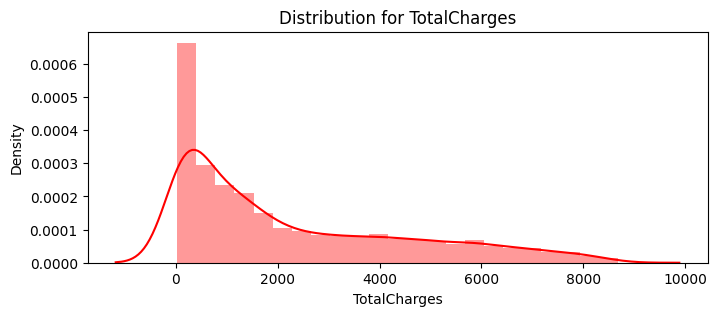

In [4]:
#in ra distribution của hàng loạt các cột numerical trước khi bị standardize
def distplot(feature, frame, color='r'):
    plt.figure(figsize=(8,3))
    plt.title("Distribution for {}".format(feature))
    ax = sns.distplot(frame[feature], color= color)
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: distplot(feat, df)

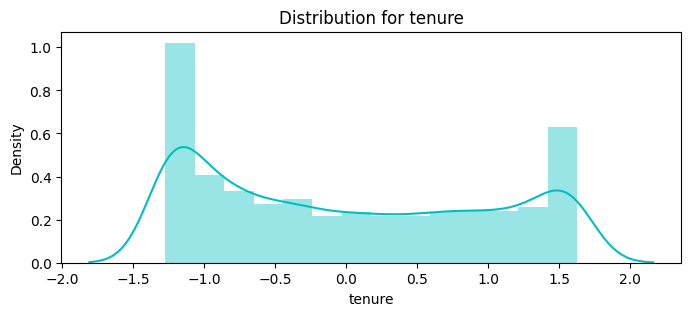

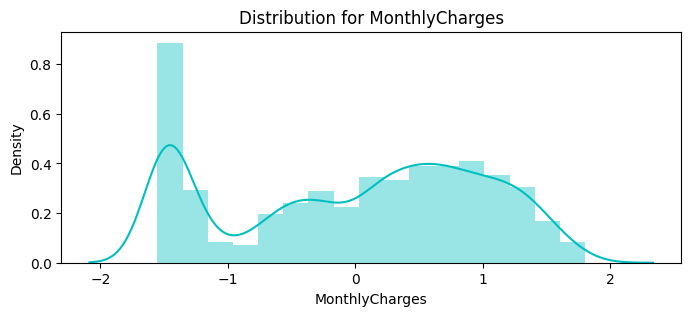

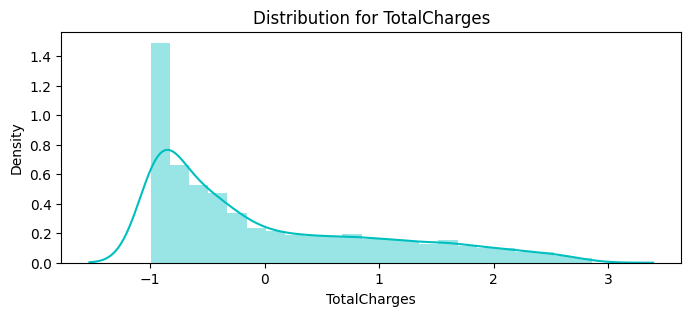

In [5]:
#giờ là cno sau khi đã standardize nè
#con vợ nào làm slide thì đặt 2 ảnh trước và sau cho thấy sự khác biệt nhé
#cụ thể là shape biểu đồ không thay đổi, chỉ đổi range của tất cả thành khoảng âm đến dương vài đơn vị thôi
df_std = pd.DataFrame(StandardScaler().fit_transform(df[num_cols].astype('float64')),
                       columns=num_cols)
for feat in num_cols: distplot(feat, df_std, color='c')

In [6]:
X_train = df.drop(columns = ['Churn'])
y_train = df['Churn'].values

df2 = pd.read_csv("../dataset/test.csv")    
X_test = df.drop(columns = ['Churn'])
y_test = df['Churn'].values

In [7]:
#mấy nhỏ ban nãy thì standardize rồi
#đám này thì one hot encoding
cat_cols_ohe =['PaymentMethod', 'Contract', 'InternetService']
#mấy nhỏ còn lại thì dùng label encoding
cat_cols_le = list(set(X_train.columns)- set(num_cols) - set(cat_cols_ohe))

In [9]:
scaler= StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [11]:
#xong việc r thì ghép lại xong lưu lại file nhé
#ghép nhỏ train
train = pd.concat([X_train, pd.Series(y_train, name="Churn")], axis=1)
#rồi đến test
test = pd.concat([X_test, pd.Series(y_test, name="Churn")], axis=1)

#lưu ra
train.to_csv("../dataset/train.csv", index=False)
test.to_csv("../dataset/test.csv", index=False)


In [ ]:
df = pd.read_csv("../dataset/train.csv")
df.head()
#giòn r

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1.506633,1,2,2,1,1,1,1,1,1,2,0,0,-1.352686,-0.275186,0
1,1,0,1,0,-0.373661,1,0,2,1,1,1,1,1,1,1,0,1,-1.517994,-0.789065,0
2,0,1,1,0,0.607362,1,2,1,2,0,0,0,0,0,0,0,2,0.520802,0.696029,1
3,1,0,0,1,-0.986800,0,1,0,2,0,0,2,0,2,2,1,3,-0.674757,-0.852543,0
4,0,0,1,1,1.629261,1,2,0,2,2,2,2,2,2,2,0,1,0.874795,1.952976,0
